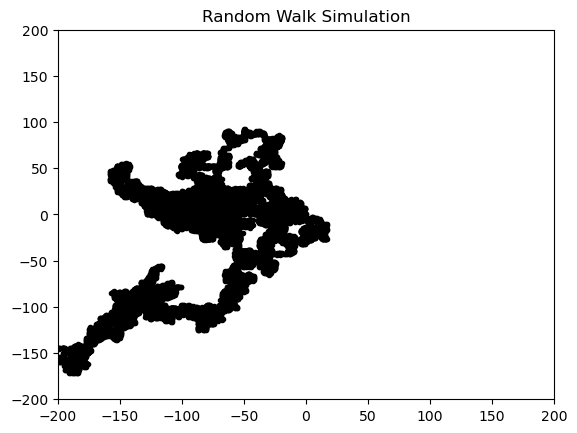

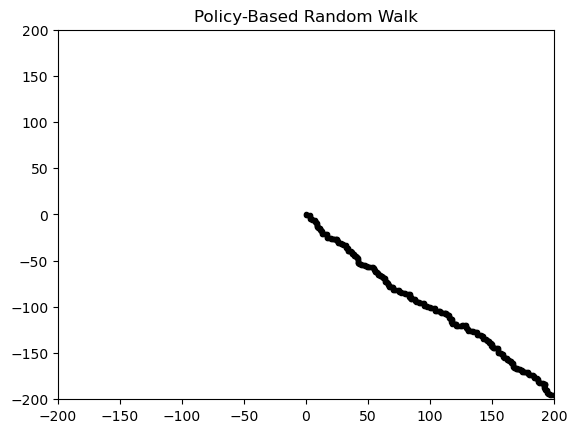

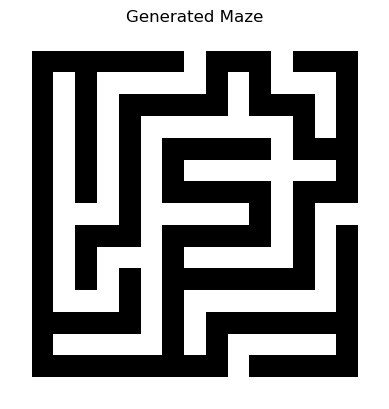

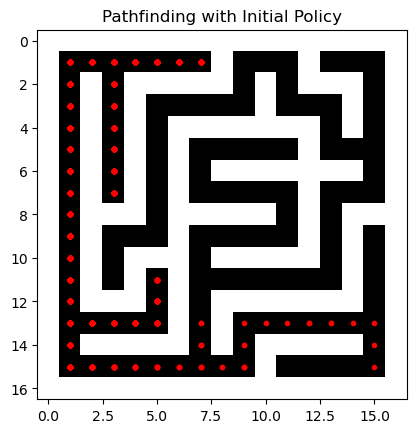

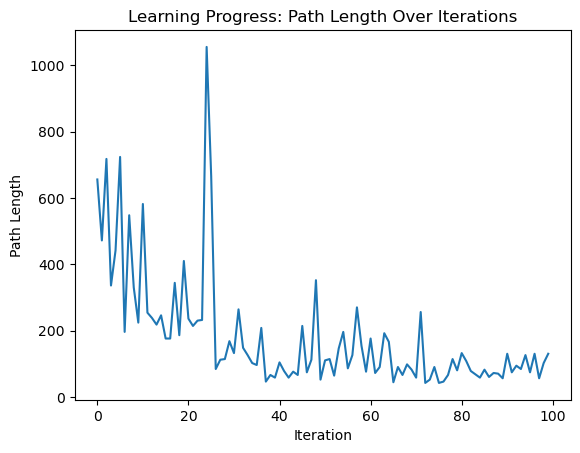

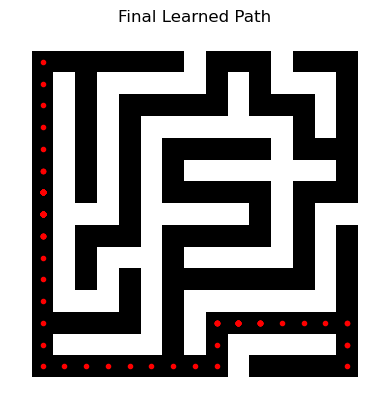

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Random Walk Simulation
# Simulate a random walk within a 200x200 boundary
X, Y = [0], [0]  # Initialize starting position

xMovement = [0, 1, 0, -1]  # Movement in the x-direction
yMovement = [1, 0, -1, 0]  # Movement in the y-direction

# Perform a random walk while staying within bounds
while np.abs(X[-1]) < 200 and np.abs(Y[-1]) < 200:
    direction = np.random.choice([0, 1, 2, 3])  # Choose random direction
    x = X[-1] + xMovement[direction]  # Update x position
    y = Y[-1] + yMovement[direction]  # Update y position
    X.append(x)
    Y.append(y)

# Plot the random walk
plt.plot(X, Y, ".k")
plt.title("Random Walk Simulation")
plt.xlim(-200, 200)
plt.ylim(-200, 200)
plt.show()

# Step 2: Policy-Based Random Walk Simulation
# Adjust probabilities for movement directions
policy = [0.01, 0.49, 0.49, 0.01]  # Probabilities for movement
X, Y = [0], [0]  # Reinitialize position

# Perform a policy-based random walk
while np.abs(X[-1]) < 200 and np.abs(Y[-1]) < 200:
    direction = np.random.choice([0, 1, 2, 3], p=policy)  # Use policy probabilities
    x = X[-1] + xMovement[direction]  # Update x position
    y = Y[-1] + yMovement[direction]  # Update y position
    X.append(x)
    Y.append(y)

# Plot the policy-based random walk
plt.plot(X, Y, ".k")
plt.title("Policy-Based Random Walk")
plt.xlim(-200, 200)
plt.ylim(-200, 200)
plt.show()

# Step 3: Maze Generation
# Create a maze using recursive backtracking
from random import shuffle

def make_maze(w=8, h=8):
    # Initialize the maze layout
    vis = [[0] * w + [1] for _ in range(h)] + [[1] * (w + 1)]
    ver = [["10"] * w + ['1'] for _ in range(h)] + [[]]
    hor = [["11"] * w + ['1'] for _ in range(h + 1)]

    # Recursive function to walk through the maze
    def walk(x, y):
        vis[y][x] = 1  # Mark position as visited
        d = [(x - 1, y), (x, y + 1), (x + 1, y), (x, y - 1)]  # Possible directions
        shuffle(d)  # Shuffle directions for randomness
        for (xx, yy) in d:
            if xx < 0 or yy < 0 or xx >= w or yy >= h or vis[yy][xx]:
                continue  # Skip invalid moves
            if xx == x:
                hor[max(y, yy)][x] = "10"  # Remove horizontal wall
            if yy == y:
                ver[y][max(x, xx)] = "00"  # Remove vertical wall
            walk(xx, yy)

    walk(np.random.randint(w), np.random.randint(h))  # Start walking

    # Combine horizontal and vertical walls to create the maze
    s = ""
    for (a, b) in zip(hor, ver):
        s += ''.join(a + ['\n'] + b + ['\n'])

    # Convert maze layout to a 2D array
    M = []
    for line in s.split("\n"):
        if line:
            R = [int(e) for e in line]
            M.append(R)
    return M

# Generate the maze
maze = np.array(make_maze(8, 8))
plt.imshow(maze, cmap="gray")  # Visualize the maze
plt.title("Generated Maze")
plt.axis("off")
plt.show()

# Step 4: Pathfinding in the Maze with Policy Adjustment
# Initialize the maze traversal
X, Y, A = [1], [1], []  # Start at (1, 1)
policy = np.ones((17, 17, 4)) / 4.0  # Equal probability for all directions

# Traverse the maze until reaching the goal (15, 15)
while not (X[-1] == 15 and Y[-1] == 15):
    x, y = X[-1], Y[-1]  # Current position
    if x < 0 or y < 0 or x >= maze.shape[0] or y >= maze.shape[1] or maze[x][y] == 1:
        break  # Stop if out of bounds or hitting a wall
    direction = np.random.choice([0, 1, 2, 3], p=policy[x][y])  # Choose action
    next_x, next_y = x + xMovement[direction], y + yMovement[direction]  # Next position
    if 0 <= next_x < maze.shape[0] and 0 <= next_y < maze.shape[1] and maze[next_x][next_y] == 0:
        X.append(next_x)  # Update path
        Y.append(next_y)
        A.append(direction)  # Log action

# Visualize the initial pathfinding attempt
plt.imshow(maze, cmap="gray")
plt.plot(Y, X, ".r")
plt.title("Pathfinding with Initial Policy")
plt.show()

# Step 5: Policy Adjustment for Learning
learning_rate = 0.01  # Define the learning rate
for i in range(len(A)):
    policy[X[i]][Y[i]][A[i]] += learning_rate  # Update policy based on actions
for x in range(17):
    for y in range(17):
        policy[x][y] /= policy[x][y].sum()  # Normalize probabilities

# Step 6: Iterative Policy Improvement
L = []  # List to track path lengths over iterations
for reps in range(100):  # Run 100 iterations
    X, Y, A = [1], [1], []  # Reset for each iteration
    while not (X[-1] == 15 and Y[-1] == 15):
        x, y = X[-1], Y[-1]  # Current position
        if x < 0 or y < 0 or x >= maze.shape[0] or y >= maze.shape[1] or maze[x][y] == 1:
            break  # Stop if invalid
        direction = np.random.choice([0, 1, 2, 3], p=policy[x][y])  # Choose action
        next_x, next_y = x + xMovement[direction], y + yMovement[direction]  # Next position
        if 0 <= next_x < maze.shape[0] and 0 <= next_y < maze.shape[1] and maze[next_x][next_y] == 0:
            X.append(next_x)  # Update path
            Y.append(next_y)
            A.append(direction)  # Log action

    L.append(len(A))  # Track path length
    learning_rate = 0.1  # Adjust learning rate
    for i in range(len(A)):
        policy[X[i]][Y[i]][A[i]] += learning_rate  # Update policy
    for x in range(17):
        for y in range(17):
            policy[x][y] /= policy[x][y].sum()  # Normalize probabilities

# Plot learning progress
plt.plot(L)
plt.title("Learning Progress: Path Length Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Path Length")
plt.show()

# Visualize the final path
plt.imshow(maze, cmap="gray")
plt.plot(Y, X, ".r")
plt.title("Final Learned Path")
plt.axis("off")
plt.show()
